In [1]:
%matplotlib widget
from dynamicsimulator import PowderSimulation, KinematicScatteringSimulator
from dynamicsimulator import DynamicScatteringSimulator
from matplotlib import pyplot as plt

## Define global parameters

In [2]:
# 1. Specimen Parameters
element = "Au"
morphology = "Icosahedron" # "Decahedron" or "Octahedron"
cluster_params = [8]
N = 5 # number of particles in powder
box_length = 100 # size of box in XY direction 
z_fraction = 0.65 # reduce box dimension along z (=box_length * z_fraction)
min_gap = 3 # minimum gap between particles in the powder
z_gap = 0 # gap between carbon grid and particles
substratefile = '/home-local/ratel-ra/Documents/ePDF_project/amorphousC/SMALL/output_xyz/aC_relax_clean_surface.xyz'
geometric_optimization = False


# 2. Parameters for scattering simulation and PDF extraction
qmin = 1.5
qmax = 23
qstep = 0.01
biso = 0.01 # isotropic ADP
rmin = 0
rmax = 50
rstep = 0.01
rpoly = 0.9
Qdamp = 0.09 # damping coefficient

## Create a powder structure file and save it

In [3]:
# Create PowderSimulation instance
p_sim = PowderSimulation(
    element=element, 
    morphology=morphology , 
    params=cluster_params, 
    N=N, 
    box_length=box_length,
    min_gap = min_gap,
    optimize=geometric_optimization)
# Generate powder deposited on C grid (provided by substratefile)
powder = p_sim.generate(substratefile = substratefile,z_gap = z_gap, z_fraction = z_fraction)
# save xyz file of powder deposited on C grid  
strufile = p_sim.save()

# Keep z coordinate of susbtrate for further use
z_C_substrate = p_sim.z_substrate


Packing clusters: 100%|██████████| 5/5 [00:03<00:00,  1.55it/s]


## Create a KinematicScatteringSimulator instance

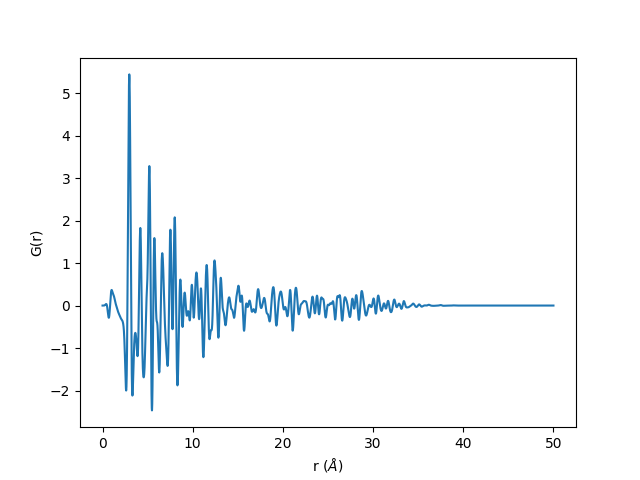

In [4]:
kinsym = KinematicScatteringSimulator(
    p_sim.path,
    element = element,
    morphology = morphology,
    params = cluster_params,
    optimize = geometric_optimization
    )

rkin, Gkin = kinsym.compute_kinematic_PDF(
        qmin = qmin,
        qmax = qmax,
        qstep = qstep,
        biso = biso,
        rmin = rmin,
        rmax = rmax,
        rstep = rstep,
        rpoly = rpoly,
        Qdamp = Qdamp,
        Lorch = True,
        plot = True,
        save = True)

## Create a DynamicScatteringSimulator instance

z axis inverted for beam view, structure is unchanged


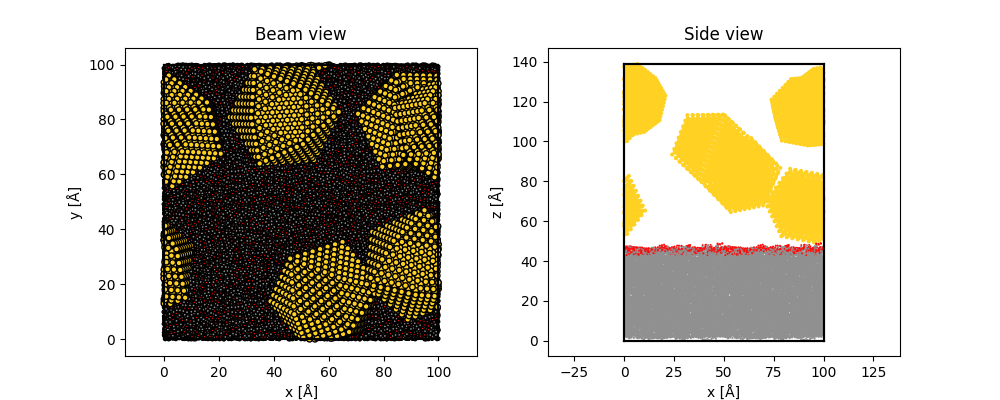

In [5]:
sim = DynamicScatteringSimulator(strufile)
sim.view_structure()

## Perform Scattering computation

We use compute2DScattering method with default parameters:
- phonon_num_configs : int, default=8
    Number of frozen phonon configurations.
- phonons_sigmas : float, default=0.1
    Standard deviation for phonon displacements.
- phonons_seed : int or None, default=None
    Random seed for reproducibility of phonon configurations.
- potential_sampling : float, default=0.1
    Real-space sampling for potential calculation (smaller -> larger reciprocal space).
- slice_thickness : float, default=1
    Thickness of each slice in Å.
- exit_planes : int, default=4
    Number of exit planes for multislice.
- voltage : float, default=3e5
    Accelerating voltage of the incident electron beam (V).
- savetag : bool, default=True
    Whether to save individual diffraction patterns as PNG images.
- videotag : bool, default=True
    Whether to generate a video from the saved diffraction patterns.
- z substrate: float
    z value corresponding to the top of the Carbon grid (used for video, to select only images corresponding to sample)

In [6]:
sim.compute2Dscattering()

Computing exit_waves
[########################################] | 100% Completed | 34.89 s
File saved: /home-local/ratel-ra/Documents/ePDF_project/Code/dynamic_scattering/powder_Icosahedron_8_Au_N=5_box=100/2D_Diffraction_Patterns//powder_Icosahedron_[8]_N=5_z=3Å.png
File saved: /home-local/ratel-ra/Documents/ePDF_project/Code/dynamic_scattering/powder_Icosahedron_8_Au_N=5_box=100/2D_Diffraction_Patterns//powder_Icosahedron_[8]_N=5_z=7Å.png
File saved: /home-local/ratel-ra/Documents/ePDF_project/Code/dynamic_scattering/powder_Icosahedron_8_Au_N=5_box=100/2D_Diffraction_Patterns//powder_Icosahedron_[8]_N=5_z=11Å.png
File saved: /home-local/ratel-ra/Documents/ePDF_project/Code/dynamic_scattering/powder_Icosahedron_8_Au_N=5_box=100/2D_Diffraction_Patterns//powder_Icosahedron_[8]_N=5_z=15Å.png
File saved: /home-local/ratel-ra/Documents/ePDF_project/Code/dynamic_scattering/powder_Icosahedron_8_Au_N=5_box=100/2D_Diffraction_Patterns//powder_Icosahedron_[8]_N=5_z=19Å.png
File saved: /home-loc

In [7]:
sim.compute1Dscattering(z_substrate=z_C_substrate)

✅ File saved: /home-local/ratel-ra/Documents/ePDF_project/Code/dynamic_scattering/powder_Icosahedron_8_Au_N=5_box=100/1D_Diffraction_Data/powder_Icosahedron_[8]_N=5_z=-1Å.iq


/home-local/ratel-ra/Documents/ePDF_project/Code/dynamic_scattering/dynamicsimulator.py:785: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(0,np.max(Iexp[q>1.5]))


 Figure saved: /home-local/ratel-ra/Documents/ePDF_project/Code/dynamic_scattering/powder_Icosahedron_8_Au_N=5_box=100/1D_Diffraction_Data/1DFigures/powder_Icosahedron_[8]_N=5_z=-1Å.png
✅ File saved: /home-local/ratel-ra/Documents/ePDF_project/Code/dynamic_scattering/powder_Icosahedron_8_Au_N=5_box=100/1D_Diffraction_Data/powder_Icosahedron_[8]_N=5_z=3Å.iq
 Figure saved: /home-local/ratel-ra/Documents/ePDF_project/Code/dynamic_scattering/powder_Icosahedron_8_Au_N=5_box=100/1D_Diffraction_Data/1DFigures/powder_Icosahedron_[8]_N=5_z=3Å.png
✅ File saved: /home-local/ratel-ra/Documents/ePDF_project/Code/dynamic_scattering/powder_Icosahedron_8_Au_N=5_box=100/1D_Diffraction_Data/powder_Icosahedron_[8]_N=5_z=7Å.iq
 Figure saved: /home-local/ratel-ra/Documents/ePDF_project/Code/dynamic_scattering/powder_Icosahedron_8_Au_N=5_box=100/1D_Diffraction_Data/1DFigures/powder_Icosahedron_[8]_N=5_z=7Å.png
✅ File saved: /home-local/ratel-ra/Documents/ePDF_project/Code/dynamic_scattering/powder_Icosahedr

In [ ]:
sim.compute_dynamic_PDF(
    qmin = 1.5,
    rpoly = 1.2,
    Qdamp = Qdamp,
    Lorch = True,
    savetag=True,
    videotag=True,
    normalizeplot=True,
    rkin=rkin,Gkin = Gkin,
    z_substrate = z_C_substrate
    )

TypeError: DynamicScatteringSimulator.compute_dynamic_PDF() got an unexpected keyword argument 'z_substrrate'